In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
df = sns.load_dataset('iris')
df = df[df['species'] != 'virginica']  # binary problem banane ke liye 2 classes lo

In [3]:
X = df[['petal_length', 'petal_width']]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
svm_hard = SVC(kernel='linear', C=1000, random_state=42)   # high C = hard margin (kam tolerance)
svm_soft = SVC(kernel='linear', C=0.1, random_state=42)     # low C = soft margin (zyada tolerance)

svm_hard.fit(X_train_scaled, y_train)
svm_soft.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
print("Hard margin (C=1000) accuracy:", accuracy_score(y_test, svm_hard.predict(X_test_scaled)))
print("Soft margin (C=0.1) accuracy:", accuracy_score(y_test, svm_soft.predict(X_test_scaled)))

Hard margin (C=1000) accuracy: 1.0
Soft margin (C=0.1) accuracy: 1.0


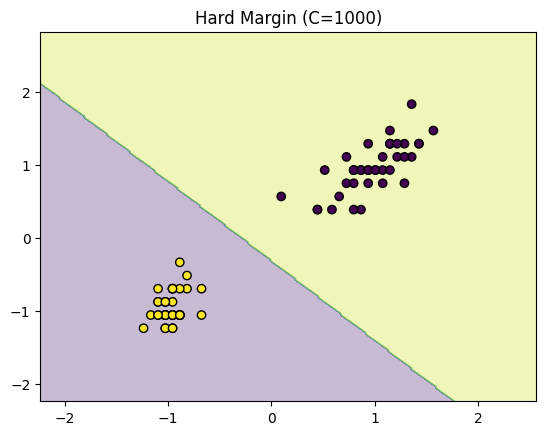

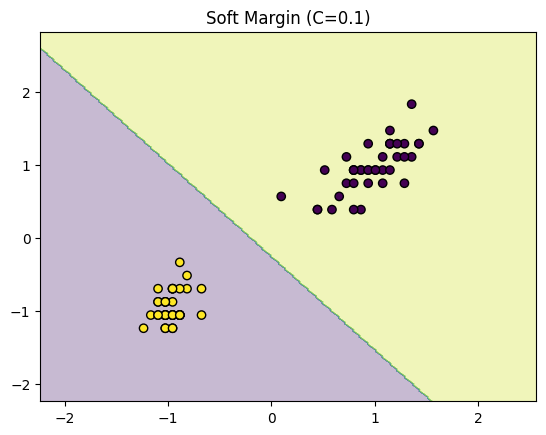

In [7]:
def plot_decision_boundary(model, X, y, title):
    X = np.array(X)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.where(Z == y.unique()[0], 0, 1).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=(y == y.unique()[0]), edgecolors='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(svm_hard, X_train_scaled, y_train, "Hard Margin (C=1000)")
plot_decision_boundary(svm_soft, X_train_scaled, y_train, "Soft Margin (C=0.1)")

In [8]:
print("Support vectors (hard margin):", svm_hard.support_vectors_.shape[0])
print("Support vectors (soft margin):", svm_soft.support_vectors_.shape[0])

Support vectors (hard margin): 2
Support vectors (soft margin): 12


In [9]:
df.shape

(100, 5)

In [10]:
df['species'].value_counts()

species
setosa        50
versicolor    50
Name: count, dtype: int64